Here's a function to subtract the background of an image based on color levels. This method works by defining a range of colors that represent the object you want to keep (or the background you want to remove). Everything outside this color range will be masked out.

**How it works:**
1.  **Convert to HSV:** The image is converted from BGR (OpenCV's default) to HSV (Hue, Saturation, Value) color space. HSV is often preferred for color-based segmentation because it separates color information (Hue) from intensity (Value), making it more robust to lighting changes.
2.  **Define Color Range:** You provide `lower_bound` and `upper_bound` tuples for the HSV values. These define the range of colors that will be considered part of the *foreground* (or the area to keep).
3.  **Create Mask:** `cv2.inRange()` creates a binary mask where pixels within the specified HSV range are white (255), and pixels outside the range are black (0).
4.  **Apply Mask:** The `cv2.bitwise_and()` operation uses this mask to isolate the foreground. It keeps only the pixels from the original image where the mask is white, effectively removing the background.

Original Image from /content/image 2.jpg:


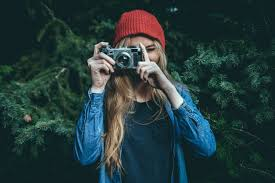


Image with Background Subtracted (Adjust HSV bounds for your object):


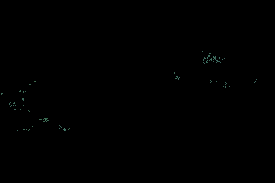

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # For displaying images in Colab

def subtract_background_by_color_levels(image_path, lower_bound, upper_bound):
    """
    Subtracts the background of an image based on a specified color range.

    Args:
        image_path (str): The path to the input image file.
        lower_bound (tuple): A tuple (H, S, V) representing the lower bound of
                             the color range for the foreground.
        upper_bound (tuple): A tuple (H, S, V) representing the upper bound of
                             the color range for the foreground.

    Returns:
        numpy.ndarray: The image with the background subtracted (masked out),
                       or None if the image cannot be loaded.
    """
    try:
        # Load the image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Error: Could not load image from {image_path}")
            return None

        # Convert the image to HSV color space
        hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

        # Create a mask for the specified color range
        # Pixels within the range will be white (255), others black (0)
        mask = cv2.inRange(hsv_image, lower_bound, upper_bound)

        # Use the mask to get the foreground object
        # The background will be black (0,0,0)
        result = cv2.bitwise_and(image, image, mask=mask)

        return result

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# --- Example Usage with your provided image ---

# Set the path to your image
user_image_path = '/content/image 2.jpg'

# Load and display the original image
original_user_image = cv2.imread(user_image_path)
if original_user_image is not None:
    print(f"Original Image from {user_image_path}:")
    cv2_imshow(original_user_image)
else:
    print(f"Error: Could not load image from {user_image_path}")

# Define the HSV color range for an object you want to detect.
# !!! IMPORTANT: These values are general and will likely need to be fine-tuned
#    for the specific color of the object you want to isolate in 'image 2.jpg'.
#    Hue (H): 0-179 (e.g., Red around 0-10 and 160-179, Green around 35-85, Blue around 100-140)
#    Saturation (S): 0-255 (amount of color)
#    Value (V): 0-255 (brightness/intensity)

# As an example, let's keep the previous green range as a starting point,
# but you will need to adjust these for the colors in 'image 2.jpg'.
lower_bound_hsv = np.array([35, 100, 100]) # Example: green lower bound
upper_bound_hsv = np.array([85, 255, 255]) # Example: green upper bound

# Apply the function to subtract the background
foreground_object = subtract_background_by_color_levels(user_image_path, lower_bound_hsv, upper_bound_hsv)

if foreground_object is not None:
    print("\nImage with Background Subtracted (Adjust HSV bounds for your object):")
    cv2_imshow(foreground_object)
else:
    print("Failed to process the image.")
